# 🔗 Hands-On Bab 9 — Visualisasi
### Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi

Notebook ini mempraktikkan visualisasi statis (NetworkX + Matplotlib) dan interaktif (PyVis), membandingkan tata letak (layout), serta mengerjakan **Latihan Soal Bab 9**.

In [1]:
!pip install -q networkx matplotlib pyvis
import networkx as nx
import matplotlib.pyplot as plt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 11.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.2 MB/s eta 0:00:00


## 9.2 Perbandingan Tata Letak (Layout)

Reproduksi ide dari Tabel 9.2: bandingkan beberapa algoritma layout pada graf yang sama.

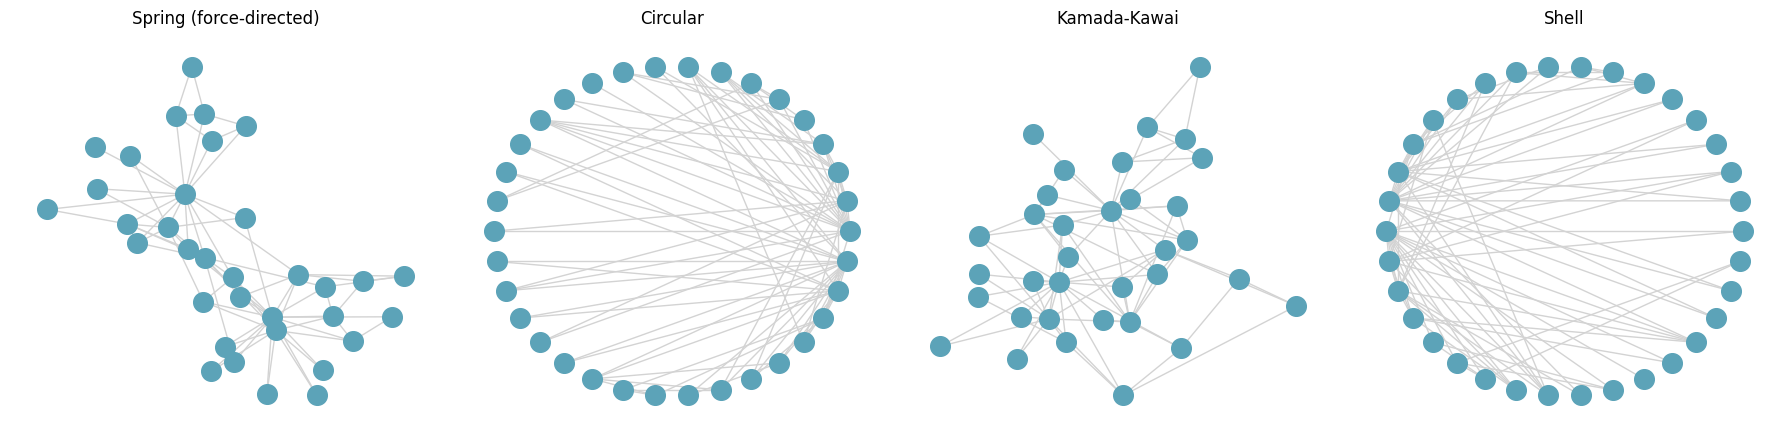

In [2]:
G_layout = nx.karate_club_graph()

layouts = {
    "Spring (force-directed)": nx.spring_layout(G_layout, seed=42),
    "Circular": nx.circular_layout(G_layout),
    "Kamada-Kawai": nx.kamada_kawai_layout(G_layout),
    "Shell": nx.shell_layout(G_layout),
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for ax, (nama, pos) in zip(axes, layouts.items()):
    nx.draw(G_layout, pos, ax=ax, node_color="#5CA3B8", node_size=200, edge_color="lightgray")
    ax.set_title(nama)
plt.tight_layout()
plt.show()

## 9.3.1 NetworkX dan Matplotlib (Visualisasi Statis)

Reproduksi kode persis dari buku: visualisasi Zachary's Karate Club dengan spring layout.

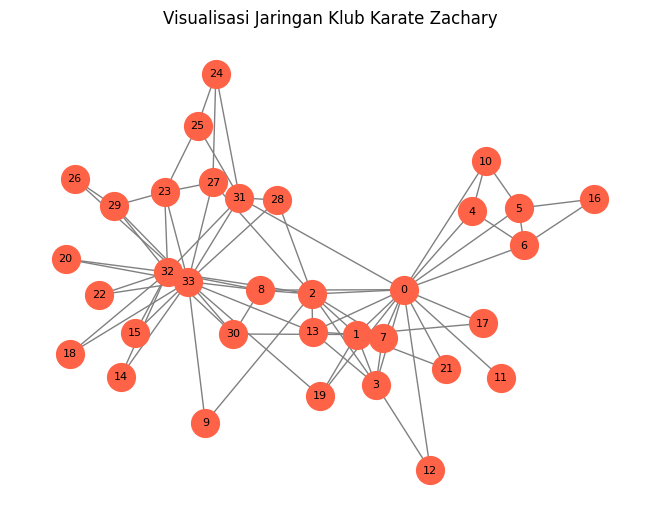

In [3]:
G = nx.karate_club_graph()
pos = nx.spring_layout(G)

nx.draw(G, pos,
        with_labels=True,
        node_color='tomato',
        node_size=400,
        edge_color='gray',
        font_size=8)

plt.title("Visualisasi Jaringan Klub Karate Zachary")
plt.show()

## ✅ Latihan Soal Bab 9

**1.** Sebuah tim peneliti perlu membuat visualisasi jaringan kolaborasi penulis (500 simpul) untuk dimasukkan ke dalam artikel jurnal cetak. Perangkat mana yang paling tepat digunakan? Jelaskan alasannya berdasarkan kebutuhan output dan karakteristik perangkat tersebut.

**2.** Seorang mahasiswa berargumen bahwa "Gephi sudah cukup untuk semua kebutuhan visualisasi jaringan sehingga tidak perlu belajar pemrograman seperti NetworkX." Apakah Anda setuju dengan pernyataan tersebut? Berikan argumen yang mendukung maupun argumen yang menyanggah pernyataan ini.

**3.** Menggunakan dataset Zachary's Karate Club, buatlah visualisasi statis dengan ketentuan: (a) tata letak Kamada-Kawai, (b) ukuran simpul proporsional terhadap degree centrality, (c) warna simpul berdasarkan hasil deteksi komunitas Louvain, dan (d) simpan hasil dalam resolusi 300 dpi format PNG.

**4.** Impor dataset edge list (CSV) ke dalam Gephi. Jalankan ForceAtlas2, hitung modularity, atur warna simpul berdasarkan komunitas, ekspor sebagai PDF/SVG. *(Soal ini dikerjakan langsung di aplikasi Gephi — lihat catatan di bawah)*

### ✏️ Jawaban Soal 1–2 (tulis di sini)

_1._

_2._

### 🧮 Soal 3 — Visualisasi

In [ ]:
G_soal3 = nx.karate_club_graph()

# (a) Tata letak Kamada-Kawai
pos = nx.kamada_kawai_layout(G_soal3)

# (b) Ukuran simpul proporsional terhadap degree centrality
degree_cent = nx.degree_centrality(G_soal3)
node_sizes = [3000 * degree_cent[n] + 100 for n in G_soal3.nodes()]

# (c) Warna simpul berdasarkan komunitas Louvain
komunitas = nx.community.louvain_communities(G_soal3, seed=42)
color_map = {}
for i, c in enumerate(komunitas):
    for node in c:
        color_map[node] = i
node_colors = [color_map[n] for n in G_soal3.nodes()]

plt.figure(figsize=(8, 7))
nx.draw(G_soal3, pos, with_labels=True, node_size=node_sizes, node_color=node_colors,
        cmap=plt.cm.Set2, edge_color="lightgray", font_size=8)
plt.title("Karate Club -- Kamada-Kawai layout, ukuran=degree, warna=komunitas Louvain")

# (d) Simpan dalam 300 dpi PNG
plt.savefig("karate_club_soal3.png", dpi=300, bbox_inches="tight")
plt.show()
print("Tersimpan sebagai karate_club_soal3.png (300 dpi)")

### 📝 Soal 4 — Catatan

Soal ini dilakukan di aplikasi **Gephi** (bukan Python), yaitu: impor CSV edge list, jalankan layout ForceAtlas2, hitung modularity via menu Statistics, atur warna lewat panel Appearance, lalu ekspor via tab Preview. Kerjakan langsung di aplikasi Gephi dan lampirkan tangkapan layar pada laporan Anda.

Anda dapat mengekspor edge list dari notebook ini untuk diimpor ke Gephi:

In [ ]:
import csv

with open("edge_list_karate.csv", "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["Source", "Target"])
    for u, v in G_soal3.edges():
        writer.writerow([u, v])

print("edge_list_karate.csv siap diimpor ke Gephi (menu Data Laboratory -> Import Spreadsheet)")

---
### 📚 Referensi
Bab 9 — *Visualisasi*, dalam **Analisis Jaringan Sosial: Konsep, Metode, dan Aplikasi**.

Lanjutkan ke **Notebook Bab 10 — Aplikasi AJS**.